# Import

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans

# if you edit the function you need to run these lines again otherwise it won't be updated in this notebook
import importlib, plotting_functions
importlib.reload(plotting_functions) 
from plotting_functions import plot_opinions, plot_opinion_change, plot_opinions_grid, plot_methods

# Functions

## Updating Functions

In [77]:
#updating functions
def one_step(index, agent, agents, advertisers, R):
    
    if advertisers is None:
        total = agents
    else:
        total = np.concatenate((agents, advertisers))

    selected = np.where(np.abs(total - agent) <= R)[0]
    update = np.average(total[selected])
    
    return update

def poll_step(index, agent, agents, advertisers, R):

    if advertisers is None:
        total = np.round(np.delete(agents, index), 1)
    else:
        total = np.concatenate((np.round(np.delete(agents, index), 1), advertisers)) #agents and advertisers with current agent removed
        
    selected = np.where(np.abs(total - agent) <= R)[0]
    update = np.average(np.append(total[selected], agent))

    return update

def skewed_confidence(index, agent, agents, advertisers, R):

    if advertisers is None:
        total = agents
    else:
        total = np.concatenate((agents, advertisers))

    if isinstance(R, float):
        raise ValueError("For skewed confidence, R must be a list of length two!")

    R_left, R_right = R


    right = (total <= (agent + R_right)) & (total >= agent)
    left = (total >= (agent - R_left)) & (total <= agent)

    selected = np.where(left | right)[0]

    update = np.average(total[selected])

    return update


## Advertising Functions

In [78]:
#advertising strategies
def constant_advertising(agents, advertisers, target, round=None):
    return advertisers


def stepwise_advertising(agents, advertisers, target, round):
    if round % 5 == 0:
        advertisers = (advertisers + 0.05) % 1
    else:
        advertisers = advertisers

    return advertisers


def targeted_clusters(agents, k=4):
    agents_arr = np.array(agents).reshape(-1, 1)
    kmeans = KMeans(n_clusters=k, n_init='auto').fit(agents_arr)
    centers = np.sort(kmeans.cluster_centers_.flatten())
    return centers


def cluster_guided_advertising(agents, advertisers, target, round=None):
    
    delta = 0.07
    m = len(advertisers)

    # compute cluster centers
    centers = targeted_clusters(agents)  
    k = len(centers)

    # initialize new advertisers array
    new_advertisers = np.zeros(m)

    # size of each block
    block = m // k

    for i, center in enumerate(centers):
        start = i * block
        end = (i + 1) * block if i < k - 1 else m  # last block takes the rest

        # amount of advertisers in this block
        size = end - start

        # assign based on center vs target
        if center < target:
            new_advertisers[start:end] = np.ones(size)*min(center + delta, 1)
            # print(center, min(center + delta, 1))
        elif center > target:
            new_advertisers[start:end] = np.ones(size)*max(center - delta, 0)
            # print(center, min(center + delta, 1))
        else:
            new_advertisers[start:end] = advertisers[start:end]

    return new_advertisers

def cluster_guided_advertising2(agents, advertisers, target, round=None):
    
    delta = 0.07
    m = len(advertisers)

    # compute cluster centers
    centers = targeted_clusters(agents)  
    k = len(centers)

    #ignore centers too near 1 
    epsilon = 1e-3 #tolerance
    filtered = centers[np.abs(centers - 1) > epsilon]

    #find max center
    if filtered.size > 0:
        center = np.max(filtered)
    else:
        center = None 

    #place all advertisers by this max center
    if center is not None:
        if center < target:
            new_advertisers = np.ones(m)*min(center + delta, 1)
        elif center > target:
            new_advertisers = np.ones(m)*max(center - delta, 0)
        else:
            print('center = target, this is a bug!')
            new_advertisers = advertisers
    else:
        new_advertisers = advertisers
        print('no centers are far enough from 1. leaving advertisers as is')
    

    return new_advertisers



## Model Function

In [79]:

def opinion_model(agents, R, rounds, advertisers=None, advert_strat=constant_advertising, update_func = one_step, target=1):

    #number of agents
    n = len(agents)
    

    #initialize array to store opinions over time
    agents_history = np.zeros((rounds + 1, n))
    agents_history[0, :] = agents

    if advertisers is not None:
        m = len(advertisers)
        advertisers_history = np.zeros((rounds + 1, m))
        advertisers_history[0, :] = advertisers
    else:
        advertisers_history = None

    #do t time steps (main loop)
    for r in range(rounds):

        #make a temp list of agents
        agents_next = np.zeros(n)

        # update advertisers
        if advertisers is not None:
            advertisers = advert_strat(agents, advertisers, target, round = r)

            # advertisers = np.copy(advertisers_next)
            advertisers_history[r + 1, :] = advertisers
            
        else:
            pass

        #loop over all agents
        for i, a in enumerate(agents):
            agents_next[i] = update_func(i, a, agents, advertisers, R)

        #update the agents list
        agents = np.copy(agents_next)
        agents_history[r + 1, :] = agents

        

    return agents, agents_history, advertisers, advertisers_history
 

# Set up

In [80]:
#set seed for reproducibility
np.random.seed(123) 

# set initial opinions & advertisers
n = 1000 #number of agents
agents = np.random.uniform(0, 1, n)

m = 50 #number of advertisers

In [139]:
R = 0.1
rounds = 365

# Testing

## No advertising

In [140]:
_, agents_history_1, _, advertisers_history_1 = opinion_model(agents = agents, 
                                                                                 R = R, rounds = rounds, 
                                                                                 advertisers = None, 
                                                                                 advert_strat = None, 
                                                                                 update_func = one_step)

No advertisers


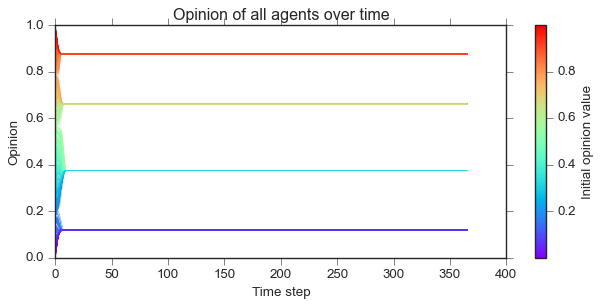

In [141]:
plot_opinions(agents_history_1, agents_history_1[0, :], rounds = rounds, alpha=0.6)

## Constant Advertising

In [142]:
advertisers = np.linspace(0.8, 1, m)

In [143]:
_, agents_history_2, _, advertisers_history_2 = opinion_model(agents = agents, 
                                                                                 R = R, rounds = rounds, 
                                                                                 advertisers = advertisers, 
                                                                                 advert_strat = constant_advertising, 
                                                                                 update_func = one_step)

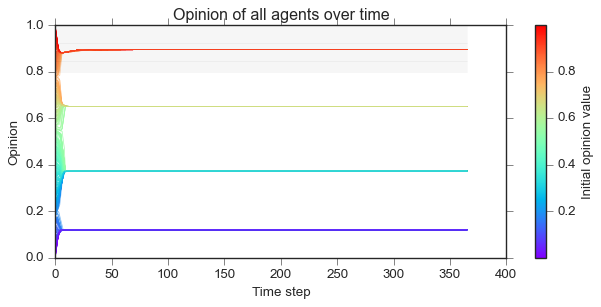

In [144]:
plot_opinions(agents_history_2, agents_history_2[0, :], advertisers_history_2, advertisers_history_2[0, :], rounds = rounds, alpha=0.6)

## Stepwise Advertising

In [145]:
# advertisers = np.linspace(0, 0.2, m)
advertisers = np.ones(m)*0.1


In [146]:
_, agents_history_3, _, advertisers_history_3 = opinion_model(agents = agents, 
                                                                                 R = R, rounds = rounds, 
                                                                                 advertisers = advertisers, 
                                                                                 advert_strat = stepwise_advertising, 
                                                                                 update_func = one_step)

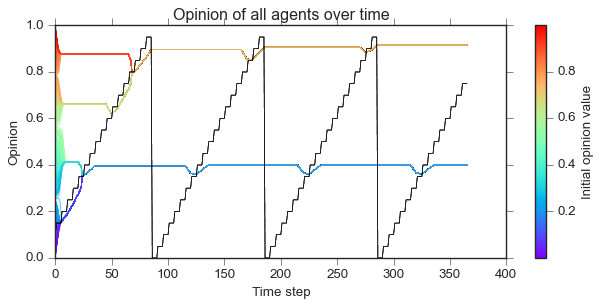

In [147]:
plot_opinions(agents_history_3, agents_history_3[0, :], advertisers_history_3, advertisers_history_3[0, :], rounds = rounds, alpha=0.6)

## Cluster-Guided

In [148]:
advertisers = np.ones(m)*0.1

In [149]:
_, agents_history_4, _, advertisers_history_4 = opinion_model(agents = agents, 
                                                                                 R = R, rounds = rounds, 
                                                                                 advertisers = advertisers, 
                                                                                 advert_strat = cluster_guided_advertising, 
                                                                                 update_func = one_step)

c:\Users\rosie\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1365: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\rosie\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1365: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\rosie\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1365: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\rosie\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1365: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly du

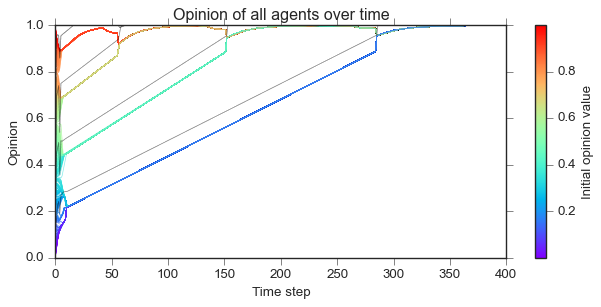

In [150]:
plot_opinions(agents_history_4, agents_history_4[0, :], advertisers_history_4, advertisers_history_4[0, :], rounds = rounds, alpha=0.6)

## Cluster Guided 2 

In [151]:
advertisers = np.ones(m)*0.1

In [152]:
_, agents_history_5, _, advertisers_history_5 = opinion_model(agents = agents, 
                                                                                 R = R, rounds = rounds, 
                                                                                 advertisers = advertisers, 
                                                                                 advert_strat = cluster_guided_advertising2, 
                                                                                 update_func = one_step)

c:\Users\rosie\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1365: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\rosie\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1365: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\rosie\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1365: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\rosie\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1365: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly du

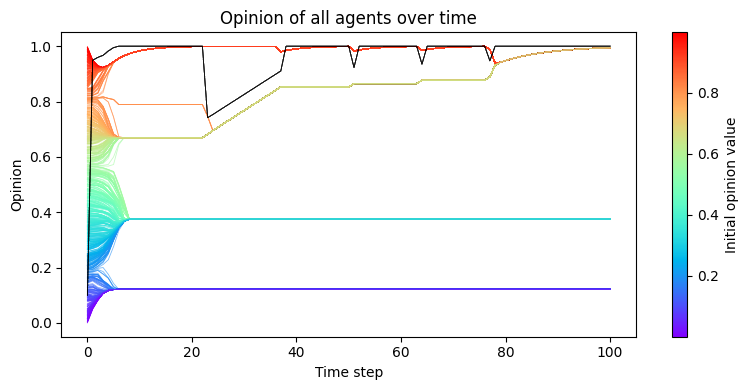

In [95]:
plot_opinions(agents_history_5, agents_history_5[0, :], advertisers_history_5, advertisers_history_5[0, :], rounds = rounds, alpha=0.6)

# Plot in grid

In [159]:
import seaborn as sns

# sns.set_style("minimal")
print(plt.style.available)
plt.style.use('default')

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


No advertisers


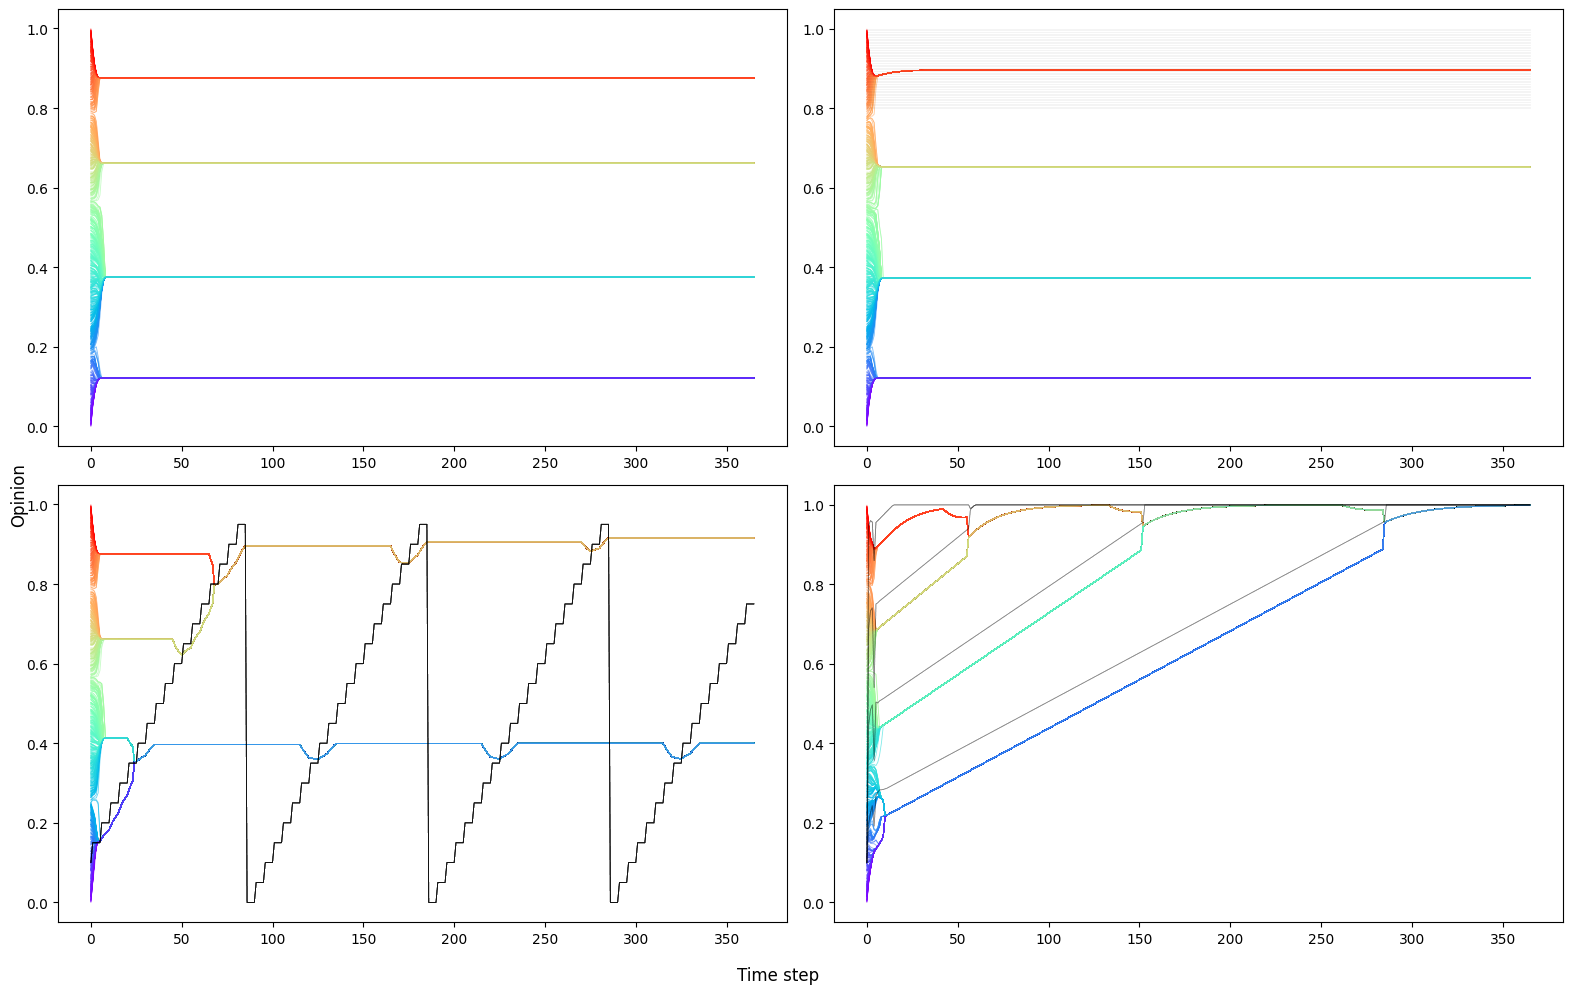

In [160]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))


datasets = [
    (agents_history_1, agents_history_1[0, :], None, None, 'None'),
    (agents_history_2, agents_history_2[0, :], advertisers_history_2, advertisers_history_2[0, :], 'Constant'),
    (agents_history_3, agents_history_3[0, :], advertisers_history_3, advertisers_history_3[0, :], 'Stepwise'),
    (agents_history_4, agents_history_4[0, :], advertisers_history_4, advertisers_history_4[0, :], 'Cluster Guided'),
]


for ax, (a_hist, a_init, adv_hist, adv_init, method) in zip(axes.flatten(), datasets):
    plot_opinions_grid(a_hist, a_init, adv_hist, adv_init, rounds=rounds, alpha=0.6, ax=ax)

fig.supxlabel("Time step")
fig.supylabel("Opinion")

plt.tight_layout()
plt.show()


colour [0.5 0.  1.  1. ] was used
colour [0.00196078 0.70928131 0.92328911 1.        ] was used
colour [0.50392157 0.99998103 0.70492555 1.        ] was used
colour [1.         0.70054304 0.37841105 1.        ] was used


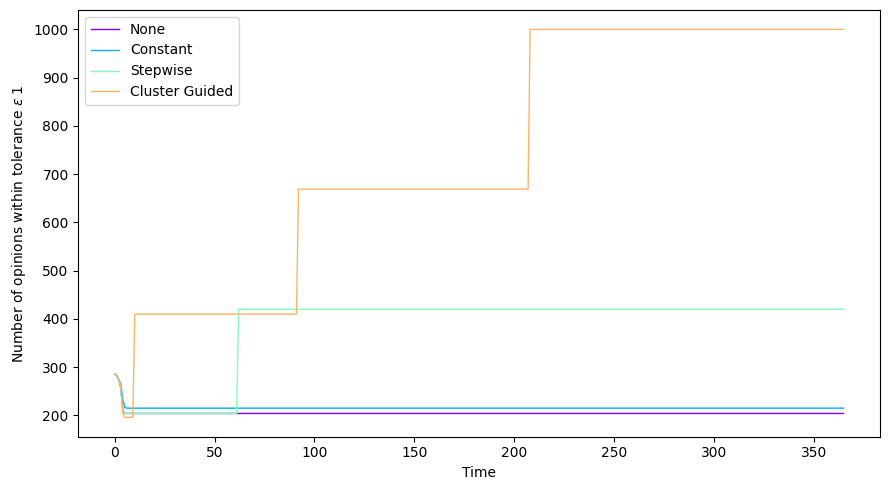

In [165]:

fig, ax = plt.subplots(figsize=(9,5))

# colours = ["#f4c021", "#f90e0e", "#1bdd0a", "#1a88ef",  "#d866fa"]
colours = plt.cm.rainbow(np.linspace(0, 1, 5))

for i, (a_hist, a_init, adv_hist, adv_init, method) in enumerate(datasets):
    plot_methods(a_hist, ax=ax, colour=colours[i], method=method, tolerance=0.3, linewidth=1)

ax.legend()
plt.tight_layout()
plt.show()



colour #f4c021 was used
colour #f90e0e was used
colour #1bdd0a was used
colour #1a88ef was used


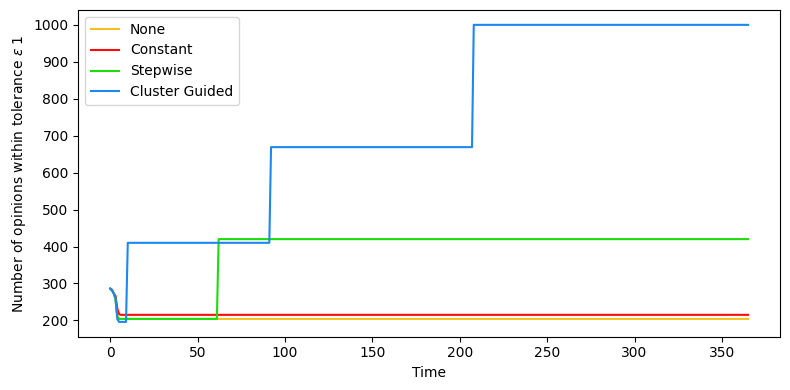

In [162]:

fig, ax = plt.subplots(figsize=(8,4))

colours = ["#f4c021", "#f90e0e", "#1bdd0a", "#1a88ef",  "#d866fa"]

for i, (a_hist, a_init, adv_hist, adv_init, method) in enumerate(datasets):
    plot_methods(a_hist, ax=ax, colour=colours[i], method=method, tolerance=0.3)

ax.legend()
plt.tight_layout()
plt.show()
